In [149]:
# import libraries 
# import dataset in 2 variable or 2 part
# check shape of each
# show image in greyscale
# Normalization
# Flatting 
# sequentional model
# compile
# fit 


In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential

import warnings
warnings.filterwarnings("ignore")

In [151]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [152]:
X_train.shape     # 3D array 

(60000, 28, 28)

In [153]:
y_train.shape  # 1D array

(60000,)

In [154]:
X_test.shape

(10000, 28, 28)

In [155]:
y_test.shape 

(10000,)

In [156]:
#print(keras.datasets.mnist.load_data())
#print(len(keras.datasets.mnist.load_data()))

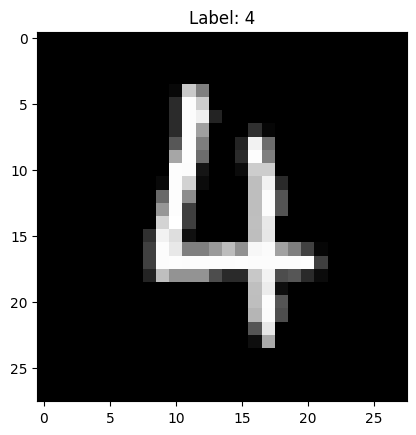

In [157]:
# Lets see visually how digit looks like

plt.imshow(X_train[1232], cmap='grey')
plt.title(f"Label: {y_train[1232]}")
plt.show()

In [158]:
X_train[1232]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   8, 201, 127,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  43, 252, 205,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [159]:
y_train[1232]

np.uint8(4)

In [160]:
# Lets normalise the data , in this case need to divide data by 255.0
# Large values → unstable learning
# So we scale to: 0 to 1
# Neural networks learn better with smaller values also improves accuracy

X_train = X_train / 255.0  # converts values between 0 and 1
X_test = X_test / 255.0    # converts values between 0 and 1

In [161]:
X_train[1232]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [162]:
# ANN doesn’t understand images directly → we convert to vector
# so need to convert image (28x28) into 1D vector
# (not dataset, it will be 2D)

X_train_flattened = X_train.reshape(-1, 784) 
X_test_flattened = X_test.reshape(-1, 784)

In [163]:
X_train_flattened

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [164]:
# Lets build model
# used dropout to reduce overfitting

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # Dense(128) -> 128 neurons active
    Dropout(0.2),                                       # 128 neurons -> ~102 active, random ~26 neurons OFF
    Dense(64, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 64 neurons -> ~51 active, random ~13 neurons OFF
    Dense(32, activation='relu'),                       # Outputs from remaining active neurons
    Dropout(0.2),                                       # 32 -> ~26 active,random ~6 neurons OFF
    Dense(10, activation='sigmoid')                     # Outputs from remaining active neurons
])

# compile model
# optimizer = 'adam' Automatically adjusts learning rate Works well in most cases

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# Lets train model
# epochs=5 ,Entire dataset is passed 5 times
model.fit(X_train_flattened, y_train, epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.8753 - loss: 0.4230
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.9452 - loss: 0.2006
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9572 - loss: 0.1556
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9624 - loss: 0.1350
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9667 - loss: 0.1180


In [165]:
# Lets evaluate model  to check real performance (Test Accuracy)
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9727 - loss: 0.0951


[0.09512984752655029, 0.9726999998092651]

In [166]:
y_predict = model.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [167]:
y_predict[0]

array([1.6079567e-06, 7.0297614e-02, 3.6994863e-01, 2.2475512e-01,
       2.5781661e-03, 6.1373012e-03, 7.9928263e-08, 9.9999815e-01,
       5.9789751e-04, 7.0011979e-01], dtype=float32)

In [168]:
print(np.argmax(y_predict[1232]))

4


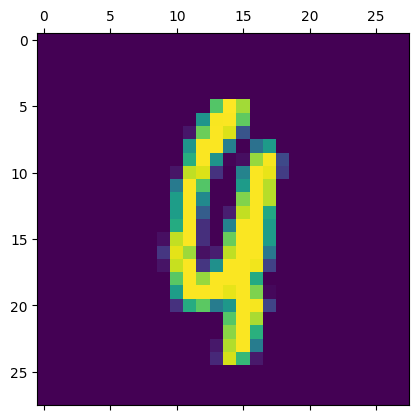

In [169]:
plt.matshow(X_test[1232])

In [170]:
# Now lets export model using keras
model.save("digit_recognition_model.keras")